In [1]:
!pip install xgboost joblib --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
uploaded = files.upload()

# Replace with your uploaded file name if needed
file_name = "train.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print(df.head())
print(df.info())

Saving train.csv to train.csv
Dataset loaded successfully.
Shape: (913000, 4)
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB
None


In [4]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates().copy()


Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate rows: 0


In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store", "item", "date"]).reset_index(drop=True)

print("\nDate range:", df["date"].min(), "to", df["date"].max())


Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [6]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

In [7]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [8]:
lag_days = [1, 2, 3, 7, 14, 21, 28]

for lag in lag_days:
    df[f"lag_{lag}"] = df.groupby(["store", "item"])["sales"].shift(lag)

In [10]:
rolling_windows = [7, 14, 30]

for window in rolling_windows:
    df[f"rolling_mean_{window}"] = (
        df.groupby(["store", "item"])["sales"]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

    df[f"rolling_std_{window}"] = (
        df.groupby(["store", "item"])["sales"]
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

In [12]:
df["expanding_mean"] = (
    df.groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Recent trend features
df["trend_1_7"] = df["lag_1"] - df["lag_7"]
df["trend_7_14"] = df["lag_7"] - df["lag_14"]

In [13]:
df = df.dropna().reset_index(drop=True)

In [14]:
before_drop = df.shape[0]
df = df.dropna().reset_index(drop=True)
after_drop = df.shape[0]

print(f"\nRows before dropna: {before_drop}")
print(f"Rows after dropna : {after_drop}")


Rows before dropna: 898000
Rows after dropna : 898000


In [15]:
df["sales_log"] = np.log1p(df["sales"])

In [16]:
train_df = df[df["date"] < "2017-10-01"].copy()
valid_df = df[df["date"] >= "2017-10-01"].copy()

print("\nTrain shape:", train_df.shape)
print("Validation shape:", valid_df.shape)


Train shape: (852000, 34)
Validation shape: (46000, 34)


In [17]:
feature_cols = [
    "store",
    "item",
    "day_of_week",
    "day_of_month",
    "month",
    "year",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",
    "expanding_mean",
    "trend_1_7",
    "trend_7_14"
]

X_train = train_df[feature_cols]
y_train = train_df["sales_log"]

X_valid = valid_df[feature_cols]
y_valid = valid_df["sales_log"]

print("\nNumber of features:", len(feature_cols))


Number of features: 31


In [19]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100
)

[0]	validation_0-rmse:0.56019	validation_1-rmse:0.54115
[100]	validation_0-rmse:0.16189	validation_1-rmse:0.16147
[200]	validation_0-rmse:0.15590	validation_1-rmse:0.15844
[300]	validation_0-rmse:0.15346	validation_1-rmse:0.15809
[400]	validation_0-rmse:0.15160	validation_1-rmse:0.15794
[500]	validation_0-rmse:0.15013	validation_1-rmse:0.15793
[600]	validation_0-rmse:0.14896	validation_1-rmse:0.15787
[700]	validation_0-rmse:0.14797	validation_1-rmse:0.15784
[800]	validation_0-rmse:0.14713	validation_1-rmse:0.15783
[900]	validation_0-rmse:0.14642	validation_1-rmse:0.15783
[1000]	validation_0-rmse:0.14586	validation_1-rmse:0.15782
[1100]	validation_0-rmse:0.14547	validation_1-rmse:0.15783
[1199]	validation_0-rmse:0.14513	validation_1-rmse:0.15783


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=-1, num_parallel_tree=None, ...)

In [20]:
valid_pred_log = model.predict(X_valid)
valid_pred = np.expm1(valid_pred_log)
y_valid_actual = np.expm1(y_valid)

# Avoid negative predictions
valid_pred = np.clip(valid_pred, 0, None)

In [21]:
mae = mean_absolute_error(y_valid_actual, valid_pred)
rmse = np.sqrt(mean_squared_error(y_valid_actual, valid_pred))

# MAPE with zero protection
mape = np.mean(
    np.abs((y_valid_actual - valid_pred) / np.maximum(y_valid_actual, 1))
) * 100

print("\n================ MODEL EVALUATION ================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")


================ MODEL EVALUATION ================
MAE  : 5.8891
RMSE : 7.6458
MAPE : 12.68%



Top 15 Important Features:
            feature  importance
23  rolling_mean_14    0.468599
22   rolling_mean_7    0.206154
18            lag_7    0.132994
24  rolling_mean_30    0.052409
2       day_of_week    0.040699
19           lag_14    0.018501
13  day_of_week_sin    0.018042
8        is_weekend    0.009780
14  day_of_week_cos    0.005839
15            lag_1    0.005730
20           lag_21    0.005266
4             month    0.004475
11        month_sin    0.003792
12        month_cos    0.002843
3      day_of_month    0.002394


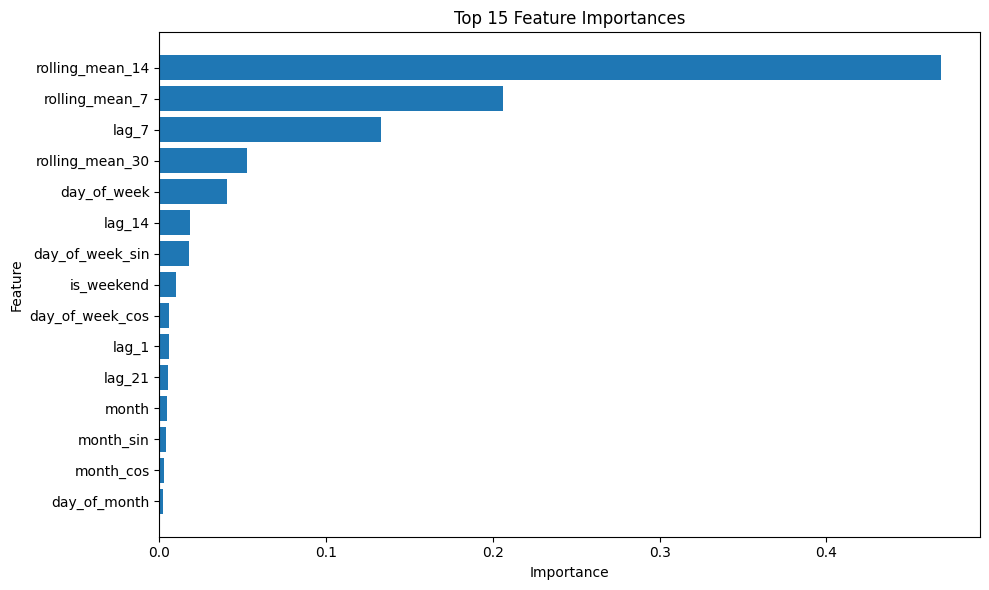

In [22]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
top_features = importance_df.head(15)
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [23]:
joblib.dump(model, "xgboost_pos_forecasting_model.pkl")
joblib.dump(feature_cols, "xgboost_feature_columns.pkl")

print("\nModel saved as xgboost_pos_forecasting_model.pkl")
print("Feature list saved as xgboost_feature_columns.pkl")

# Download saved files to your computer if needed
files.download("xgboost_pos_forecasting_model.pkl")
files.download("xgboost_feature_columns.pkl")


Model saved as xgboost_pos_forecasting_model.pkl
Feature list saved as xgboost_feature_columns.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
sample_output = valid_df[["date", "store", "item", "sales"]].copy()
sample_output["predicted_sales"] = np.round(valid_pred, 2)
sample_output["abs_error"] = np.abs(sample_output["sales"] - sample_output["predicted_sales"])

print("\nSample predictions:")
print(sample_output.head(20))

# Save predictions
sample_output.to_csv("validation_predictions.csv", index=False)
files.download("validation_predictions.csv")


Sample predictions:
           date  store  item  sales  predicted_sales  abs_error
1704 2017-10-01      1     1     21        24.219999   3.219999
1705 2017-10-02      1     1     12        16.420000   4.420000
1706 2017-10-03      1     1     18        20.510000   2.510000
1707 2017-10-04      1     1     15        19.290001   4.290001
1708 2017-10-05      1     1     20        21.290001   1.290001
1709 2017-10-06      1     1     19        21.980000   2.980000
1710 2017-10-07      1     1     22        24.600000   2.600000
1711 2017-10-08      1     1     19        25.350000   6.350000
1712 2017-10-09      1     1      9        17.110001   8.110001
1713 2017-10-10      1     1     23        18.930000   4.070000
1714 2017-10-11      1     1     14        20.320000   6.320000
1715 2017-10-12      1     1     24        20.790001   3.209999
1716 2017-10-13      1     1     23        21.889999   1.110001
1717 2017-10-14      1     1     26        22.719999   3.280001
1718 2017-10-15    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
def create_future_features_for_one_product(full_df, store_id, item_id, future_date):
    """
    Build one-row feature input for future prediction using latest available history
    """
    product_df = full_df[(full_df["store"] == store_id) & (full_df["item"] == item_id)].copy()
    product_df = product_df.sort_values("date").reset_index(drop=True)

    if product_df.empty:
        raise ValueError("No history found for the given store/item.")

    # Use the original sales data from cleaned dataset
    sales_series = product_df["sales"].tolist()

    future_date = pd.to_datetime(future_date)

    row = {}
    row["store"] = store_id
    row["item"] = item_id
    row["day_of_week"] = future_date.dayofweek
    row["day_of_month"] = future_date.day
    row["month"] = future_date.month
    row["year"] = future_date.year
    row["week_of_year"] = int(future_date.isocalendar().week)
    row["quarter"] = future_date.quarter
    row["is_weekend"] = int(future_date.dayofweek in [5, 6])
    row["is_month_start"] = int(future_date.is_month_start)
    row["is_month_end"] = int(future_date.is_month_end)

    row["month_sin"] = np.sin(2 * np.pi * row["month"] / 12)
    row["month_cos"] = np.cos(2 * np.pi * row["month"] / 12)
    row["day_of_week_sin"] = np.sin(2 * np.pi * row["day_of_week"] / 7)
    row["day_of_week_cos"] = np.cos(2 * np.pi * row["day_of_week"] / 7)

    # Lag features
    for lag in lag_days:
        if len(sales_series) >= lag:
            row[f"lag_{lag}"] = sales_series[-lag]
        else:
            row[f"lag_{lag}"] = np.nan

    # Rolling features
    for window in rolling_windows:
        if len(sales_series) >= window:
            row[f"rolling_mean_{window}"] = np.mean(sales_series[-window:])
            row[f"rolling_std_{window}"] = np.std(sales_series[-window:])
        else:
            row[f"rolling_mean_{window}"] = np.mean(sales_series)
            row[f"rolling_std_{window}"] = np.std(sales_series)

    row["expanding_mean"] = np.mean(sales_series)
    row["trend_1_7"] = row["lag_1"] - row["lag_7"]
    row["trend_7_14"] = row["lag_7"] - row["lag_14"]

    future_features = pd.DataFrame([row])

    # Fill any accidental missing values
    future_features = future_features.fillna(0)

    return future_features[feature_cols]

In [26]:
example_store = 1
example_item = 1
future_date = "2018-01-01"

future_X = create_future_features_for_one_product(df, example_store, example_item, future_date)
future_pred_log = model.predict(future_X)[0]
future_pred = np.expm1(future_pred_log)
future_pred = max(0, future_pred)

print("\n================ FUTURE FORECAST EXAMPLE ================")
print(f"Store: {example_store}")
print(f"Item : {example_item}")
print(f"Date : {future_date}")
print(f"Predicted Sales: {future_pred:.2f} units")


================ FUTURE FORECAST EXAMPLE ================
Store: 1
Item : 1
Date : 2018-01-01
Predicted Sales: 11.54 units


In [27]:
current_stock = 20
safety_stock = 10
predicted_next_7_days = future_pred * 7

required_stock = predicted_next_7_days + safety_stock
reorder_qty = max(0, int(np.ceil(required_stock - current_stock)))

print("\n================ REORDER SUGGESTION EXAMPLE ================")
print(f"Current Stock         : {current_stock}")
print(f"Predicted Next 7 Days : {predicted_next_7_days:.2f}")
print(f"Safety Stock          : {safety_stock}")
print(f"Suggested Reorder Qty : {reorder_qty}")


================ REORDER SUGGESTION EXAMPLE ================
Current Stock         : 20
Predicted Next 7 Days : 80.76
Safety Stock          : 10
Suggested Reorder Qty : 71


In [28]:
forecast_examples = []

for item_id in [1, 2, 3, 4, 5]:
    try:
        fx = create_future_features_for_one_product(df, 1, item_id, "2018-01-01")
        pred_log = model.predict(fx)[0]
        pred_sales = max(0, np.expm1(pred_log))

        forecast_examples.append({
            "store": 1,
            "item": item_id,
            "forecast_date": "2018-01-01",
            "predicted_sales_next_day": round(pred_sales, 2)
        })
    except Exception as e:
        print(f"Skipping item {item_id}: {e}")

forecast_df = pd.DataFrame(forecast_examples)
print("\nForecast examples:")
print(forecast_df)

forecast_df.to_csv("forecast_examples.csv", index=False)
files.download("forecast_examples.csv")


Forecast examples:
   store  item forecast_date  predicted_sales_next_day
0      1     1    2018-01-01                 11.540000
1      1     2    2018-01-01                 32.560001
2      1     3    2018-01-01                 20.090000
3      1     4    2018-01-01                 10.440000
4      1     5    2018-01-01                  8.800000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>